# PINN 代码实战课件：从 RC 电路到芯片热分析

> 配套推文《PINN 代码实战》的**可运行课件版本**。三个例子共用同一套「最小 PINN 配方」，难度递进：一维 RC 电路 → 二维芯片热分析 → 一维 PN 结泊松方程。
>
> **运行方式**：从上到下依次执行即可（依赖 `torch` / `numpy` / `scipy` / `matplotlib`）。RC 例子很快；芯片与 PN 结含 L-BFGS 精修，用时视机器而定。
>
> 讲解顺序参考公开 PINN 教程（见文末致谢）；所有数字均来自本课件在本机的实跑输出。


## 环境准备


In [1]:
# ── 基础库 ──
import numpy as np                                       # 数值数组与线性代数
import torch                                             # 张量 + 自动微分（PINN 的核心引擎）
import torch.nn as nn                                    # 神经网络层与损失函数
import matplotlib.pyplot as plt                          # 画图
from matplotlib.colors import LinearSegmentedColormap    # 自定义温度色带用

%matplotlib inline                                       # 图直接嵌进 notebook 显示
torch.manual_seed(0)                                     # 固定 torch 随机种子（结果可复现）
np.random.seed(0)                                        # 固定 numpy 随机种子

# 中文字体 + 简洁风格（否则中文会显示成方框）
plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],  # 依次找可用中文字体
    "axes.unicode_minus": False,                         # 负号正常显示（避免变方块）
    "figure.dpi": 110,                                   # 显示分辨率
    "axes.spines.top": False,                            # 去掉上边框
    "axes.spines.right": False,                          # 去掉右边框
    "axes.grid": True,                                   # 默认显示网格
    "grid.color": "#e1e0d9",                             # 浅灰网格线
})

# 全局配色，正文各图统一使用
BLUE, ORANGE, TEAL = "#2a78d6", "#eb6834", "#1baf7a"     # 蓝 / 橙 / 青
INK, MUTED = "#0b0b0b", "#898781"                        # 墨黑（前景）/ 灰（辅助）
print("PyTorch", torch.__version__)                      # 打印版本，确认环境就绪


PyTorch 2.10.0+cpu


## 0. 最小可用配方

无论方程是什么，经典 PINN 都是同样四步：

1. **用网络表示未知函数** $u_\theta(x)$；
2. **在配点上用自动微分算「方程残差」**——把方程整理成「应当为 0」的形式；
3. **损失 = 数据项 + 物理项**；
4. **优化**：先 Adam 探索，需要时再用 L-BFGS 精修（简单问题如后面的 RC 仅用 Adam 即可）。

唯一的关键是自动微分里的 `create_graph=True`：它让「对坐标求导」得到的残差仍挂在计算图上，于是训练时「对网络参数求导」（第二层）才能把物理项梯度回传。去掉它，第二层就拿不到物理项的梯度（甚至直接报错）——这是最常见的坑。

下面所有例子都复用这个公共单元格里的 `MLP` 和 `grad`。


In [2]:
class MLP(nn.Module):
    # 通用全连接网络（多层感知机）：tanh 激活，二阶导非零，适合含二阶导的 PDE
    def __init__(self, n_in=1, n_out=1, width=32, depth=3):
        super().__init__()
        layers, d = [], n_in                        # layers 收集各层；d 记录当前层的输入维度
        for _ in range(depth):                       # 堆叠 depth 个「线性层 + tanh」隐藏块
            layers += [nn.Linear(d, width), nn.Tanh()]
            d = width                                # 下一层的输入维度变成 width
        layers += [nn.Linear(d, n_out)]              # 最后一层线性输出（不加激活）
        self.net = nn.Sequential(*layers)            # 打包成顺序执行的模型

    def forward(self, *xs):
        # 支持多坐标输入（如 x,y）：多输入就在最后一维拼接，单输入直接用
        return self.net(torch.cat(xs, dim=1) if len(xs) > 1 else xs[0])


def grad(y, x):
    # 对输入求一阶导 dy/dx；grad_outputs=ones 表示逐元素求导
    # create_graph=True 让这次求导本身仍挂在计算图上——才能对结果再次求导（PINN 的第二层）
    return torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]


## 1. 热身 · RC 电路的充电与外推

电阻 $R$ 串联电容 $C$，接电源 $V_s$ 充电。电容电压满足一阶线性 ODE

$$
\frac{dV}{dt}=\frac{V_s-V}{\tau},\qquad \tau=RC,
$$

解析解是 $V(t)=V_s\bigl(1-e^{-t/\tau}\bigr)$，用来对照检验。

我们故意设成一个**外推**问题：只在早期充电段 $t\in[0,0.3]$ 给 12 个带噪测量点，却要预测到 $t=1$（由解析式此时约为 $V_s$ 的 $96.4\%$，是**接近稳态的后期过程**，并非已精确到稳态）。物理残差就是把方程移项 $\dfrac{dV}{dt}-\dfrac{V_s-V}{\tau}$，配点铺满整个 $[0,1]$（包括没有数据的外推区）。


In [3]:
# 物理常数：电源电压 / 时间常数 τ=RC / 观测窗口 / 数据覆盖到的时间 / 测量噪声幅度
V_S, TAU, T_END, T_DATA, NOISE = 5.0, 0.30, 1.0, 0.30, 0.15

def exact(t):                                        # 解析解，仅用于对照检验
    return V_S * (1.0 - np.exp(-t / TAU))            # V(t) = V_s (1 - e^{-t/τ})

# 稀疏带噪测量：只取早期充电段 [0, 0.3]（约一个 τ），共 12 个点
t_data = np.linspace(0.0, T_DATA, 12)                # 测量时刻
V_data = exact(t_data) + NOISE * np.random.randn(t_data.size)  # 真解 + 高斯噪声
td = torch.tensor(t_data, dtype=torch.float32).view(-1, 1)     # 转成列向量张量 (N,1)
Vd = torch.tensor(V_data, dtype=torch.float32).view(-1, 1)     # 同上

# 配点：在整个 [0,1] 均匀铺 200 个点（含无数据的外推区），物理残差将在这里被要求成立
# requires_grad_(True)：要对这些时间坐标求导（算 dV/dt），所以打开梯度追踪
t_coll = torch.linspace(0.0, T_END, 200).view(-1, 1).requires_grad_(True)
print("数据点", t_data.size, " 配点", t_coll.shape[0])


数据点 12  配点 200


In [4]:
def train_rc(use_physics, discover=False, epochs=8000, lr=5e-3):
    model = MLP(1, 1, width=32, depth=3)                          # 1 输入(t) → 1 输出(V)
    # 反问题：把 1/τ（速率）设成可训练参数，从 0.5 起步（真值 1/0.3≈3.33）
    inv_rate = nn.Parameter(torch.tensor([0.5])) if discover else None
    params = list(model.parameters()) + ([inv_rate] if discover else [])  # τ 与网络一起优化
    opt = torch.optim.Adam(params, lr=lr)                         # Adam 优化器

    trace = []                                                   # 记录 τ 估计随训练的变化
    for ep in range(epochs):
        opt.zero_grad()                                          # 清空上一步累积的梯度
        loss = nn.functional.mse_loss(model(td), Vd)             # ① 数据损失：拟合 12 个测量点
        if use_physics:
            V = model(t_coll)                                    # 在配点上预测电压
            rate = inv_rate if discover else torch.tensor(1.0 / TAU)  # 正问题用真值，反问题用可学参数
            res = grad(V, t_coll) - rate * (V_S - V)            # ② RC 残差 dV/dt-(V_s-V)/τ
            loss = loss + torch.mean(res ** 2)                  # 总损失 = 数据 + 物理
        loss.backward(); opt.step()                             # 反向传播并更新参数
        if discover and ep % 40 == 0:
            trace.append((ep, 1.0 / float(inv_rate.detach())))  # 每 40 步记一次当前 τ 估计
    tau_hat = 1.0 / float(inv_rate.detach()) if discover else None  # 由 1/τ 反推 τ
    return model, tau_hat, trace

net_data, _, _ = train_rc(use_physics=False)                     # 纯数据网络（只拟合，无物理）
net_pinn, _, _ = train_rc(use_physics=True)                      # PINN 正问题（τ 已知）
net_disc, tau_hat, trace = train_rc(use_physics=True, discover=True)  # 反问题（τ 未知，自己学）
print(f"反问题恢复 tau = {tau_hat:.4f}  (真值 {TAU})")


反问题恢复 tau = 0.3067  (真值 0.3)


全区间相对误差  纯数据 0.103    PINN 0.019
数据点拟合 MSE  纯数据 0.0000    PINN 0.0167    (噪声方差 σ²=0.0225)


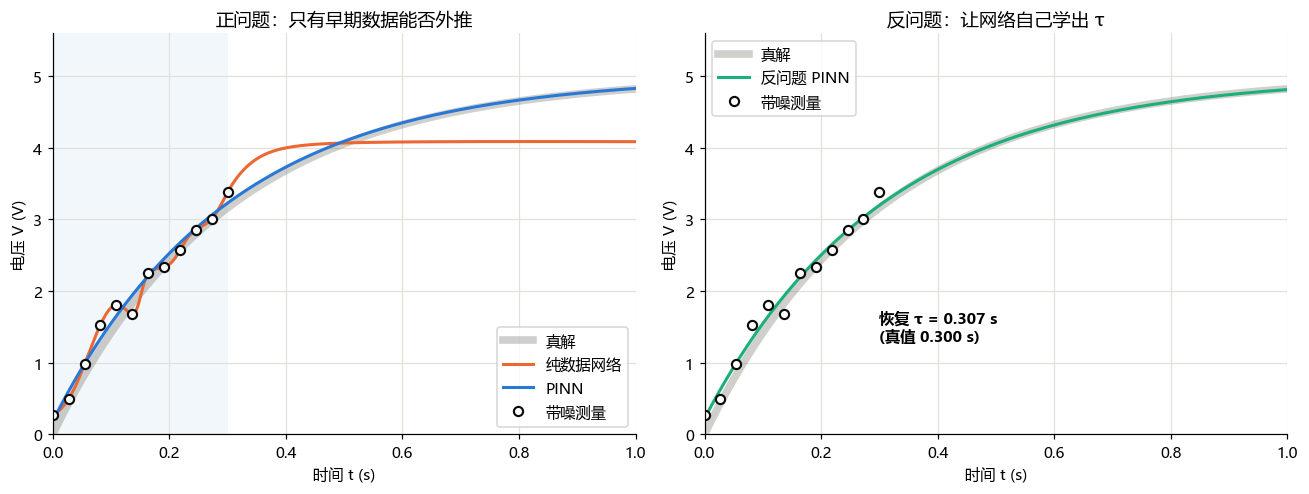

In [5]:
# ── 在整个区间上评估三个模型，并与真解对比 ──
tt = np.linspace(0.0, T_END, 400)                            # 细网格，画光滑曲线用
ttt = torch.tensor(tt, dtype=torch.float32).view(-1, 1)
with torch.no_grad():                                        # 纯评估，不需要梯度
    y_data = net_data(ttt).numpy().ravel()                  # 纯数据网络的预测
    y_pinn = net_pinn(ttt).numpy().ravel()                  # PINN 正问题的预测
    y_disc = net_disc(ttt).numpy().ravel()                  # 反问题 PINN 的预测
y_true = exact(tt)                                          # 解析真解

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))     # 左右两栏

# 左图：正问题外推对比
axL.axvspan(0, T_DATA, color=BLUE, alpha=0.06, lw=0)        # 阴影标出「有数据」区间
axL.plot(tt, y_true, color=MUTED, lw=5, alpha=0.4, label="真解")   # 灰粗底线 = 真解
axL.plot(tt, y_data, color=ORANGE, lw=2, label="纯数据网络")        # 橙线：外推会失真
axL.plot(tt, y_pinn, color=BLUE, lw=2, label="PINN")              # 蓝线：外推贴住真解
axL.plot(t_data, V_data, "o", ms=6, mfc="white", mec=INK, mew=1.4, label="带噪测量")  # 测量点
axL.set(xlim=(0, T_END), ylim=(0, V_S * 1.12), xlabel="时间 t (s)", ylabel="电压 V (V)")
axL.set_title("正问题：只有早期数据能否外推")
axL.legend(loc="lower right")

# 右图：反问题——从带噪数据反推 τ
axR.plot(tt, y_true, color=MUTED, lw=5, alpha=0.4, label="真解")
axR.plot(tt, y_disc, color=TEAL, lw=2, label="反问题 PINN")
axR.plot(t_data, V_data, "o", ms=6, mfc="white", mec=INK, mew=1.4, label="带噪测量")
axR.set(xlim=(0, T_END), ylim=(0, V_S * 1.12), xlabel="时间 t (s)", ylabel="电压 V (V)")
axR.set_title("反问题：让网络自己学出 τ")
axR.legend(loc="upper left")
axR.text(0.30, 1.3, f"恢复 τ = {tau_hat:.3f} s\n(真值 {TAU:.3f} s)", fontweight="bold")  # 标注结果
plt.tight_layout(); plt.show()

# 相对 L2 误差——注意 rel 用的是全部 400 点，是全区间 [0,1] 的误差，不止外推段
rel = lambda y: np.linalg.norm(y - y_true) / np.linalg.norm(y_true)
print(f"全区间相对误差  纯数据 {rel(y_data):.3f}    PINN {rel(y_pinn):.3f}")

# 关键悖论：纯数据网络在「数据点上」拟合得更好，整体却更离谱
with torch.no_grad():
    mse = lambda m: float(nn.functional.mse_loss(m(td), Vd))
print(f"数据点拟合 MSE  纯数据 {mse(net_data):.4f}    PINN {mse(net_pinn):.4f}"
      f"    (噪声方差 σ²={NOISE ** 2:.4f})")


**要点**：留意上面打印出的一个悖论——纯数据网络在 12 个数据点上的 MSE 低到四位小数下显示为 $0.0000$（比噪声方差 $\sigma^2=0.0225$ 还低，说明把噪声也拟合了进去），可整个 $[0,1]$ 区间上的相对 $L_2$ 误差却高达 $0.103$；PINN 的数据 MSE 停在 $\approx\sigma^2$、不追噪声，同一相对误差反而只有 $0.019$。**「拟合数据更好」和「更接近真函数」在这里是相反的。**

原因：只用数据是**欠定**问题，$[0,0.3]$ 之外没有任何约束，网络只能凭自身光滑先验把曲线压平（tanh 饱和）。物理残差是一个**微分约束**，把函数值和导数绑定，让「无穷多条候选曲线」坍缩成 RC 方程的唯一解——它本质是一种**结构化正则**。所以 $L=L_{data}+\lambda L_{phys}$：纯数据端 $L_{data}$ 最低但 $L_{phys}$ 巨大，PINN 端 $L_{data}$ 略高却让 $L_{phys}\approx0$。**训练损失小 ≠ 解对，符合物理才是。**

反问题只多改一处：把 $1/\tau$ 从常数换成 `nn.Parameter`，让优化器在拟合曲线的同时把它一起学出来——这就是 PINN 做系统辨识的全部秘密。


## 2. 主菜 · 芯片稳态热分析

芯片上的功能模块发热不均，形成一个个**热点**，结温过高直接影响性能与寿命。稳态温度场满足二维热传导方程

$$
k\,(T_{xx}+T_{yy})+q(x,y)=0,
$$

其中 $q(x,y)$ 是功率密度（这里设成三个高斯热点），四周边界 $T=0$（散热器冷却）。残差就是把方程左边搬进损失，用自动微分求二阶导。

为检验，另用**有限差分**（5 点格式 + 稀疏直接解）独立解同一泊松问题作参考。为什么要这样：方形域 + 高斯源写不出解析真解，只能用一个独立数值解当地面真值；有限差分和 PINN 路线完全不同，两者一致才是「都对」的强证据；它对椭圆问题可证明收敛、精度 $O(h^2)$，网格够细时误差远小于 PINN，才配当「尺子」；而 PINN 训练时从没见过这份参考，是真正的留出验证。


In [6]:
K = 1.0                                   # 归一化热导率 k
# 三个发热模块（模拟 CPU 核 / IP 块）：每个是一个高斯热点 (中心x, 中心y, 幅值, 半径)
HOTSPOTS = [(0.30, 0.35, 1.0, 0.060),
            (0.66, 0.62, 1.4, 0.080),     # 幅值最大 → 最热的模块
            (0.72, 0.24, 0.8, 0.050)]

def source_np(x, y):                      # numpy 版功率密度 q(x,y)，给有限差分用
    q = np.zeros_like(x)
    for cx, cy, a, s in HOTSPOTS:         # 把每个高斯热点叠加起来
        q += a * np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * s ** 2))
    return q

def source_th(x, y):                      # torch 版同一个 q，给 PINN 残差用（可反向传播）
    q = torch.zeros_like(x)
    for cx, cy, a, s in HOTSPOTS:
        q = q + a * torch.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * s ** 2))
    return q


In [7]:
import scipy.sparse as sp                 # 稀疏矩阵
import scipy.sparse.linalg as spla        # 稀疏线性求解器

def fd_reference(n=161):
    # 有限差分参考解：把 k∇²T+q=0 离散成线性方程组 A·T=b 直接解（边界 T=0）
    h = 1.0 / (n - 1)                      # 网格步长
    xs = np.linspace(0, 1, n)             # 一维坐标
    X, Y = np.meshgrid(xs, xs, indexing="ij")   # 二维网格坐标
    m = n - 2                             # 每维内部未知点个数（去掉两端边界）
    idx = lambda i, j: i * m + j          # 二维内部下标 → 一维方程编号
    A = sp.lil_matrix((m * m, m * m)); b = np.zeros(m * m)   # 系数矩阵 A 与右端项 b
    for i in range(m):
        for j in range(m):
            p = idx(i, j); A[p, p] = -4.0             # 5 点格式的中心系数
            for di, dj in ((1, 0), (-1, 0), (0, 1), (0, -1)):  # 上下左右四个邻居
                ii, jj = i + di, j + dj
                if 0 <= ii < m and 0 <= jj < m:       # 邻居在内部才连；边界处 T=0 自动省略
                    A[p, idx(ii, jj)] = 1.0
            # 右端项：∇²T=-q/k 离散后得 A·T = -h²·q/k
            b[p] = -(h ** 2) * source_np(np.array(xs[i + 1]), np.array(xs[j + 1])) / K
    T = np.zeros((n, n))                              # 含边界的完整温度场（边界已是 0）
    T[1:-1, 1:-1] = spla.spsolve(A.tocsr(), b).reshape(m, m)  # 解方程并填回内部
    return X, Y, T

X, Y, T_ref = fd_reference(161)           # 用 161×161 网格求参考解
print("有限差分参考解完成", T_ref.shape)


有限差分参考解完成 (161, 161)


In [8]:
def laplacian(T, x, y):
    # 拉普拉斯算子 ∇²T = ∂²T/∂x² + ∂²T/∂y²，对每个方向各求两次导
    return grad(grad(T, x), x) + grad(grad(T, y), y)

def train_chip(epochs_adam=5000):
    model = MLP(2, 1, width=48, depth=5)                    # 2 输入(x,y) → 1 输出(T)
    xy = torch.rand(4000, 2)                                # 域内随机采 4000 个配点
    xf = xy[:, :1].requires_grad_(True)                    # x 坐标（要对它求导）
    yf = xy[:, 1:].requires_grad_(True)                    # y 坐标（要对它求导）
    a = torch.rand(150, 1); z0, z1 = torch.zeros(150, 1), torch.ones(150, 1)
    xb = torch.cat([a, a, z0, z1]); yb = torch.cat([z0, z1, a, a])   # 四条边上的边界点

    def terms():
        T = model(xf, yf)                                  # 配点上的温度预测
        Lf = torch.mean((K * laplacian(T, xf, yf) + source_th(xf, yf)) ** 2)  # 物理残差项
        Lb = torch.mean(model(xb, yb) ** 2)                # 边界项：逼边界温度→0（Dirichlet）
        return Lf, Lb

    # 第一阶段：Adam 粗调（快速探索）
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    for ep in range(epochs_adam):
        opt.zero_grad(); Lf, Lb = terms()
        (Lf + 20 * Lb).backward()                          # 边界权重取 20，钉住边界条件
        opt.step()
        if ep % 1000 == 0:
            print(f"  adam {ep:5d}  Lf {Lf.item():.2e}  Lb {Lb.item():.2e}")

    # 第二阶段：L-BFGS 精修（二阶优化，收敛更准）
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=2000,
                              line_search_fn="strong_wolfe")
    def closure():                                         # L-BFGS 需要一个重算损失的闭包
        lbfgs.zero_grad(); Lf, Lb = terms(); (Lf + 20 * Lb).backward()
        return Lf + 20 * Lb
    lbfgs.step(closure)
    Lf, Lb = terms(); print(f"  完成  Lf {Lf.item():.2e}  Lb {Lb.item():.2e}")
    return model

chip = train_chip()                                        # 训练（含 L-BFGS 精修，用时视机器而定）


  adam     0  Lf 5.82e-02  Lb 3.03e-03
  adam  1000  Lf 1.85e-03  Lb 2.54e-06
  adam  2000  Lf 1.36e-04  Lb 1.56e-06
  adam  3000  Lf 6.74e-05  Lb 8.86e-07
  adam  4000  Lf 4.38e-05  Lb 6.32e-07
  完成  Lf 3.96e-06  Lb 3.48e-08


相对 L2 误差 = 1.265e-02
最高温 0.0174 @ (x=0.644, y=0.606)


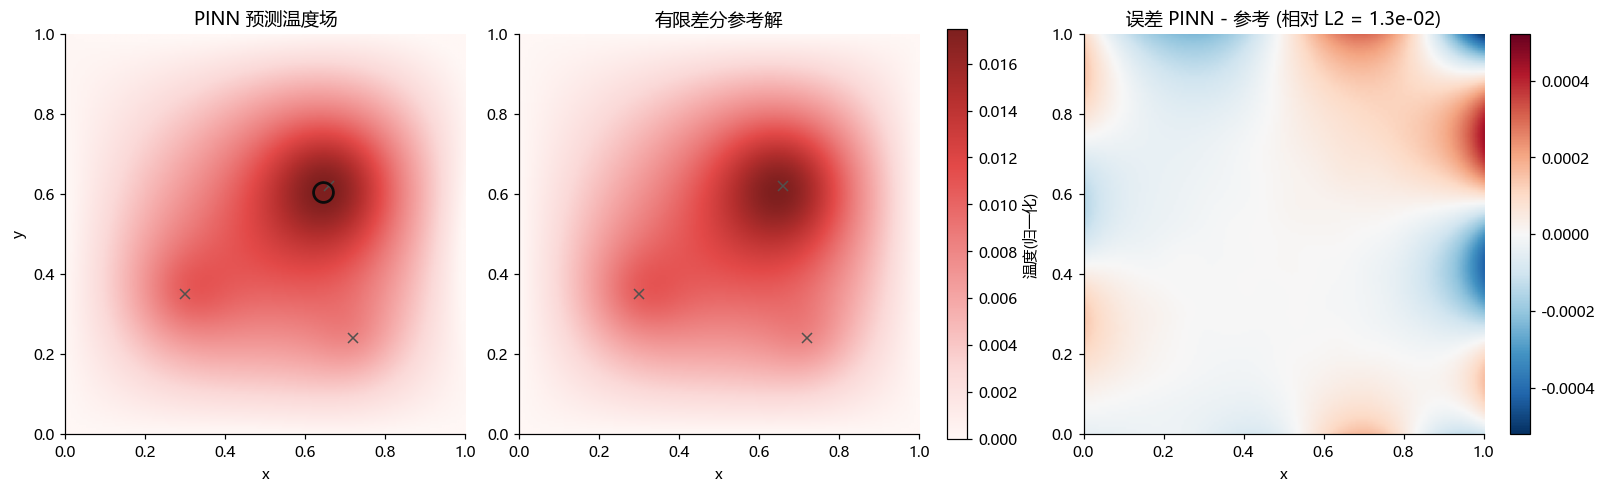

In [9]:
# ── 在有限差分同一网格上评估 PINN，并与参考解比较 ──
xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32)   # 网格点 x 展平成 (N,1)
yt = torch.tensor(Y.reshape(-1, 1), dtype=torch.float32)   # 网格点 y 展平成 (N,1)
with torch.no_grad():                                      # 评估阶段不需要梯度
    T_pinn = chip(xt, yt).numpy().reshape(X.shape)         # PINN 预测温度场，还原成网格形状

err = T_pinn - T_ref                                       # 逐点误差
rel_l2 = np.linalg.norm(err) / np.linalg.norm(T_ref)       # 相对 L2 误差
i, j = np.unravel_index(T_ref.argmax(), T_ref.shape)       # 参考解里最高温的网格位置
x_hot, y_hot, T_hot = X[i, j], Y[i, j], T_ref[i, j]        # 对应坐标与温度
print(f"相对 L2 误差 = {rel_l2:.3e}")
print(f"最高温 {T_hot:.4f} @ (x={x_hot:.3f}, y={y_hot:.3f})")

# 自定义「暖色」温度色带（浅粉 → 深红），越热越深
warm = LinearSegmentedColormap.from_list(
    "warm", ["#fff7f5", "#fbd9d8", "#f5a9a8", "#ec7b7a",
             "#e34948", "#b52f2e", "#7d1f1e"])
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4), constrained_layout=True)  # 三联图
for a in ax:
    a.grid(False)                                          # 热力图上不画网格线
vmax = max(T_pinn.max(), T_ref.max()); ext = [0, 1, 0, 1]  # 前两图共用色标上限
# 左、中两图：PINN 温度场 与 有限差分参考解（同色标便于对比）
for a, Z, title in [(ax[0], T_pinn, "PINN 预测温度场"),
                    (ax[1], T_ref, "有限差分参考解")]:
    im = a.imshow(Z.T, origin="lower", extent=ext, cmap=warm, vmin=0, vmax=vmax)
    a.set_title(title); a.set_xlabel("x")
    for cx, cy, *_ in HOTSPOTS:
        a.plot(cx, cy, "x", ms=7, color="#52514e")        # ×号标出三个热点中心
ax[0].set_ylabel("y")
ax[0].plot(x_hot, y_hot, "o", ms=13, mfc="none", mec=INK, mew=1.8)  # 圈出全局最高温点
fig.colorbar(im, ax=ax[:2], fraction=0.024, pad=0.02, label="温度(归一化)")  # 前两图共享色条

# 右图：误差图（发散色带，红正蓝负、中间白）
emax = np.abs(err).max()                                   # 对称色标范围
im2 = ax[2].imshow(err.T, origin="lower", extent=ext, cmap="RdBu_r",
                   vmin=-emax, vmax=emax)
ax[2].set_title(f"误差 PINN - 参考 (相对 L2 = {rel_l2:.1e})"); ax[2].set_xlabel("x")
fig.colorbar(im2, ax=ax[2], fraction=0.05, pad=0.04)
plt.show()


**要点**：先说**为什么训得准**——稳态热方程 + Dirichlet 边界是**适定的椭圆问题**，解唯一且光滑，正好落在 tanh 网络「低频易学」的甜区（谱偏置这次站在我们这边）；线性椭圆还有稳定性估计，解误差被残差与边界误差共同控制，所以把 $L_f,L_b$ 压到 $10^{-6}$ 量级就能保证解接近真解。残余误差主要贴在边界附近，因为边界是软约束（罚项）而非精确满足。

PINN 重建了整个温度场——图中黑圈标的是**有限差分参考解**的全局最高温位置（落在最强的那个热点附近），PINN 温度场在该处与参考几乎重合（本课件未单独统计 PINN 自身峰值的定位误差）。定位热点、估计峰值温升正是它在芯片设计里最被看好的用途——**设计探索的代理模型**：一次训练后改变热点布局再重算。不过在这种规整几何的标准正问题上，单点 PINN 的精度/速度并不比有限差分占优；工业界真正发力的是**算子学习**（一次学会「功率图→温度场」的整个映射），如 ANSYS 的热 ML 求解器、Cadence 的 DeepOHeat、NVIDIA Modulus。


## 3. 拓展 · PN 结的泊松方程

半导体器件更硬核，但其中最基础的一块——PN 结的**静电势**——单独就是一个泊松方程：

$$
\frac{d^2\varphi}{dx^2}=-\frac{\rho(x)}{\varepsilon}.
$$

耗尽近似下空间电荷密度 $\rho$ 分段常数：p 区 $-qN_A$，n 区 $+qN_D$，中性区为 0，且电荷中性 $N_A x_p=N_D x_n$。边界放在 p 侧接触 $x=-1$：$\varphi=0$ 且 $\varphi'=0$。参考解用细网格两次累积积分得到。


In [10]:
EPS = 1.0                                  # 归一化介电常数 ε
# 耗尽区宽度、掺杂浓度、半器件长度；满足电荷中性 N_A·x_p = N_D·x_n = 1.2
X_P, X_N, N_A, N_D, L = 0.40, 0.60, 3.0, 2.0, 1.0

def rho_np(x):                             # numpy 版空间电荷密度 ρ(x)
    r = np.zeros_like(x)                   # 中性区为 0
    r[(x >= -X_P) & (x < 0)] = -N_A        # p 区（受主）：负电荷
    r[(x >= 0) & (x <= X_N)] = +N_D        # n 区（施主）：正电荷
    return r

def rho_th(x):                             # torch 版同一个 ρ，用 where 实现分段（可反向传播）
    r = torch.zeros_like(x)
    r = torch.where((x >= -X_P) & (x < 0), torch.full_like(x, -N_A), r)
    r = torch.where((x >= 0) & (x <= X_N), torch.full_like(x, +N_D), r)
    return r

def reference(n=4001):                     # 参考解：对 φ''=-ρ/ε 做两次累积（梯形）积分
    xs = np.linspace(-L, L, n); rho = rho_np(xs)
    # 第一次积分得到 φ'（起点 φ'(-L)=0）
    dphi = np.concatenate([[0.], np.cumsum(0.5 * (-rho[1:] / EPS + -rho[:-1] / EPS) * np.diff(xs))])
    # 第二次积分得到 φ（起点 φ(-L)=0）
    phi = np.concatenate([[0.], np.cumsum(0.5 * (dphi[1:] + dphi[:-1]) * np.diff(xs))])
    return xs, phi, -dphi                   # 返回坐标、电势、以及电场 E = -φ'

xs, phi_ref, E_ref = reference()
print("V_bi (参考) =", round(float(phi_ref[-1]), 4))   # 内建电势 = 右端点电势


V_bi (参考) = 0.6


In [11]:
def train_pn(epochs_adam=5000):
    model = MLP(1, 1, width=40, depth=4)                       # 1 输入(x) → 1 输出(φ)
    xf = torch.linspace(-L, L, 400).view(-1, 1).requires_grad_(True)  # 400 个域内配点
    xb = torch.tensor([[-L]], dtype=torch.float32).requires_grad_(True)  # 边界点 x=-L

    def terms():
        phi = model(xf)                                        # 配点上的电势预测
        phi_xx = grad(grad(phi, xf), xf)                       # 二阶导 φ''（两次求导）
        Lf = torch.mean((phi_xx + rho_th(xf) / EPS) ** 2)      # 泊松残差 φ''+ρ/ε
        pb = model(xb)                                         # 边界处电势
        Lb = pb.pow(2).mean() + grad(pb, xb).pow(2).mean()     # 边界项：φ(-L)=0 且 φ'(-L)=0
        return Lf, Lb

    opt = torch.optim.Adam(model.parameters(), lr=3e-3)        # 第一阶段：Adam 粗调
    for ep in range(epochs_adam):
        opt.zero_grad(); Lf, Lb = terms(); (Lf + 10 * Lb).backward(); opt.step()
        if ep % 1000 == 0:
            print(f"  adam {ep:5d}  Lf {Lf.item():.2e}")

    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=2000,   # 第二阶段：L-BFGS 精修
                              line_search_fn="strong_wolfe")
    def closure():                                             # L-BFGS 的重算损失闭包
        lbfgs.zero_grad(); Lf, Lb = terms(); (Lf + 10 * Lb).backward()
        return Lf + 10 * Lb
    lbfgs.step(closure)
    Lf, Lb = terms(); print(f"  完成  Lf {Lf.item():.2e}")
    return model

pn = train_pn()


  adam     0  Lf 3.01e+00
  adam  1000  Lf 1.59e-01
  adam  2000  Lf 3.10e-02
  adam  3000  Lf 2.95e-02
  adam  4000  Lf 1.44e-02
  完成  Lf 2.55e-03


电势最大误差 = 1.943e-03
峰值电场 |E| = 1.200 @ x = 0.000


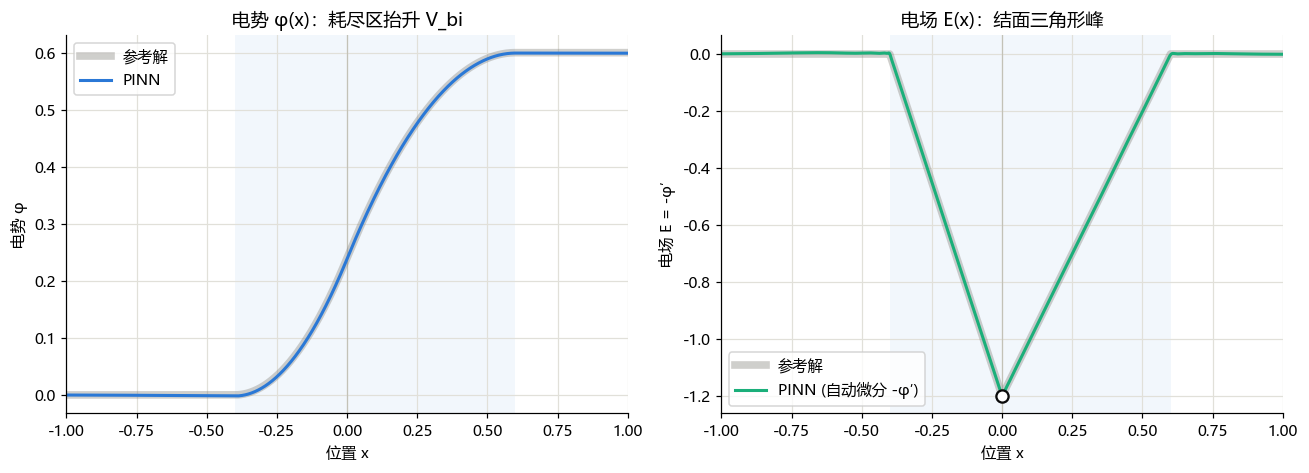

In [12]:
# ── 评估并画电势 φ 与电场 E ──
xtp = torch.tensor(xs.reshape(-1, 1), dtype=torch.float32).requires_grad_(True)  # 要对 x 求导
phi_p = pn(xtp)                                            # PINN 预测电势
E_p = (-grad(phi_p, xtp)).detach().numpy().ravel()        # 电场 E=-φ'，由自动微分直接得到
phi_pinn = phi_p.detach().numpy().ravel()                 # 电势转成 numpy
V_bi = phi_ref[-1]; i_pk = np.abs(E_ref).argmax()         # 内建电势；电场峰值所在位置
print(f"电势最大误差 = {np.max(np.abs(phi_pinn - phi_ref)):.3e}")
print(f"峰值电场 |E| = {abs(E_ref[i_pk]):.3f} @ x = {xs[i_pk]:.3f}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4))
for ax in (axL, axR):                                     # 两图都标出耗尽区与结面
    ax.axvspan(-X_P, X_N, color=BLUE, alpha=0.06, lw=0)   # 浅蓝带 = 耗尽区
    ax.axvline(0, color="#c3c2b7", lw=0.8)                # 竖线 = 结面 x=0
# 左图：电势 φ(x)
axL.plot(xs, phi_ref, color=MUTED, lw=5, alpha=0.4, label="参考解")
axL.plot(xs, phi_pinn, color=BLUE, lw=2, label="PINN")
axL.set(xlim=(-L, L), xlabel="位置 x", ylabel="电势 φ", title="电势 φ(x)：耗尽区抬升 V_bi")
axL.legend(loc="upper left")
# 右图：电场 E(x) = -φ'
axR.plot(xs, E_ref, color=MUTED, lw=5, alpha=0.4, label="参考解")
axR.plot(xs, E_p, color=TEAL, lw=2, label="PINN (自动微分 -φ′)")
axR.plot(xs[i_pk], E_ref[i_pk], "o", ms=8, mfc="white", mec=INK, mew=1.5)  # 标出峰值场
axR.set(xlim=(-L, L), xlabel="位置 x", ylabel="电场 E = -φ′", title="电场 E(x)：结面三角形峰")
axR.legend(loc="lower left")
plt.tight_layout(); plt.show()


**要点**：电场 $E=-\varphi'$ 不是额外训练的，而是对**网络本身**做精确解析求导（autograd）得来的——PINN 给出的是处处可微的闭式代理 $\varphi_\theta(x)$，求导不引入差分误差、也不放大噪声。再看误差从哪来：$\rho$ 分段常数 → $\varphi''$ 跳变、$\varphi'$ 有折点（$-x_p,0,x_n$）、$\varphi$ 分段二次；$C^\infty$ 的 tanh 网络学不出折角（刻画折角需要高频，正是谱偏置的短板），所以误差集中在这几个间断点——这跟理论篇「谱偏置/高频难学」是同一件事的另一副面孔。但零测度的折点拖不动整体 $L_2$ 误差，全局精度依旧很高。完整的漂移-扩散方程组（载流子浓度跨数量级、高度刚性、界面系数不连续）比这难得多，目前生产级器件仿真仍以经典数值求解器为主。


## 4. 小结：一套配方，三种问题

| 例子 | 方程 | 维度 | 求什么 | 典型结果 |
|---|---|---|---|---|
| RC 电路 | 一阶 ODE | 1D（时间） | 外推 + 反推 $\tau$ | 全区间相对误差 0.10→0.02；恢复 $\tau\approx0.31$（真值 0.30） |
| 芯片热分析 | 2D 稳态热方程 | 2D（空间） | 温度场 + 最高温 | 相对 $L_2$ 误差 $\sim10^{-2}$ |
| PN 结 | 泊松方程 | 1D（空间） | 电势 + 电场 | 电势误差 $\sim10^{-3}$，$V_{bi}\approx0.60$ |

复用的那套配方一句话概括：**网络表示解 → 自动微分算残差 → 损失 = 数据 + 物理 → Adam（必要时再 L-BFGS 精修）**。真正需要动脑的不在写残差，而在配点怎么采、损失权重怎么配、边界条件怎么加——这些决定训不训得动。

**什么时候用 PINN**：反问题（从数据反推参数）、代理模型（一次训练反复探索）是它的甜区；规整几何上的标准正问题，成熟网格方法往往又快又准。物理信息改善的是数据效率与物理一致性，不等于自动拿到高精度解。

---

### 致谢与版权

本课件的讲解顺序——从纯数据拟合，到加入物理约束，再到未知参数辨识——参考了 Theodore Wolf 的 PINN 教程与 Ben Moseley 的谐振子工作坊，特此致谢。三个算例的代码与配图均由本课件运行生成；芯片与器件部分的方法背景、误差分析与扩展方向见推文《PINN 代码实战》的参考文献。
